# Trabajo Final de Machine Learning - Ejercicio 3
## Clustering: perfiles de clientes mayoristas

**Grupo:** completar
**Integrantes:** completar

Se comparan K-Means y DBSCAN para identificar perfiles de clientes a partir de sus gastos anuales por categoria.

## 1. Metadata y planteamiento

El dataset Wholesale Customers contiene 440 clientes, con canal, region y gasto anual en Fresh, Milk, Grocery, Frozen, Detergents_Paper y Delicassen. Para clustering se excluyen `Channel` y `Region`, porque el objetivo es descubrir perfiles basados en comportamiento de compra, no reproducir etiquetas administrativas.

Pregunta: **es posible distinguir grupos de clientes con patrones de gasto diferentes?**

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [ ]:
DATA_PATH = Path('datasets/Wholesale_customers_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print(f'Dimensiones: {df.shape}')
display(df.head())
display(df.describe().T)

Dimensiones: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


Valores faltantes: 0


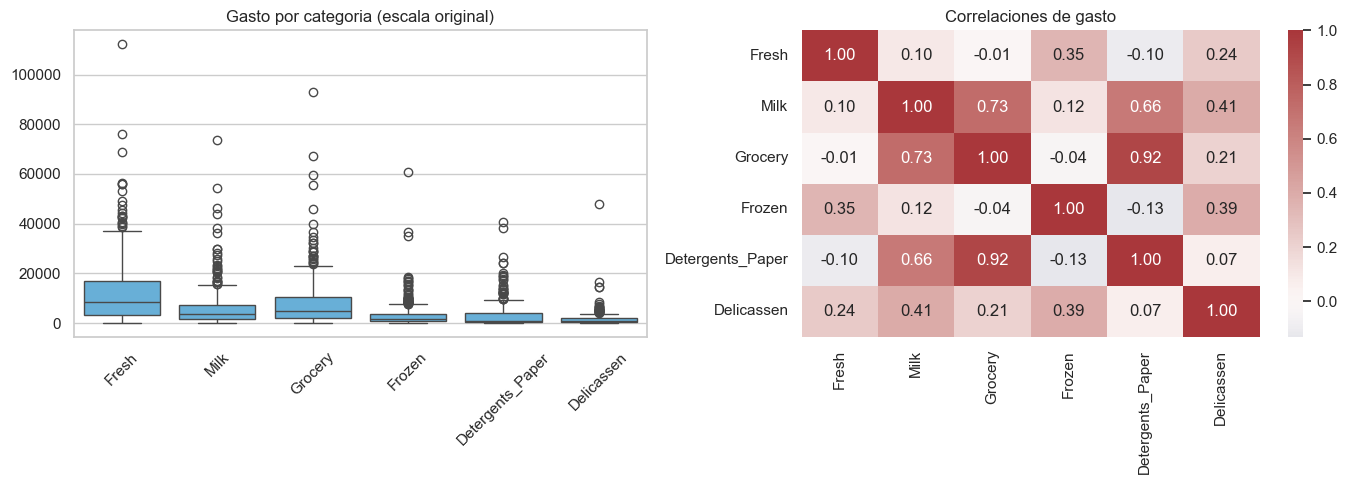

In [3]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
print('Valores faltantes:', df[spending_cols].isna().sum().sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[spending_cols], ax=axes[0], color='#56b4e9')
axes[0].set_title('Gasto por categoria (escala original)')
axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(df[spending_cols].corr(), cmap='vlag', center=0, annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Correlaciones de gasto')
plt.tight_layout()
plt.show()

# La transformacion log reduce el peso de valores extremos sin eliminar clientes.
X_log = np.log1p(df[spending_cols])
X_scaled = StandardScaler().fit_transform(X_log)

## 2. K-Means

Se usa `log1p` para reducir la asimetria de los gastos y luego se estandarizan las variables. Se comparan varios valores de K usando silhouette y Davies-Bouldin.

In [4]:
k_rows = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
    k_rows.append({'K': k, 'Silhouette': silhouette_score(X_scaled, labels), 'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)})
k_results = pd.DataFrame(k_rows)
display(k_results.style.format({'Silhouette':'{:.3f}', 'Davies-Bouldin':'{:.3f}'}))
best_k = int(k_results.loc[k_results['Silhouette'].idxmax(), 'K'])
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
print('K elegido por silhouette:', best_k)

,K,Silhouette,Davies-Bouldin
0,2,0.290,1.352
1,3,0.258,1.348
2,4,0.188,1.541
3,5,0.192,1.484
4,6,0.195,1.414
5,7,0.196,1.392
6,8,0.191,1.385


K elegido por silhouette: 2


## 3. DBSCAN

DBSCAN identifica regiones densas y permite marcar observaciones atipicas como ruido (`-1`). Se prueba una pequeña grilla de hiperparametros y se descartan configuraciones con un unico grupo valido.

In [5]:
db_rows = []
for eps in [0.7, 0.9, 1.1, 1.3, 1.5]:
    for min_samples in [4, 6, 10]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        valid = labels != -1
        groups = set(labels[valid])
        if valid.sum() > 1 and len(groups) >= 2:
            db_rows.append({'eps': eps, 'min_samples': min_samples, 'grupos': len(groups), 'ruido_%': 100 * (~valid).mean(), 'Silhouette_sin_ruido': silhouette_score(X_scaled[valid], labels[valid])})
db_results = pd.DataFrame(db_rows).sort_values('Silhouette_sin_ruido', ascending=False)
display(db_results.head(10).style.format({'ruido_%':'{:.1f}', 'Silhouette_sin_ruido':'{:.3f}'}))
if db_results.empty:
    raise ValueError('La grilla de DBSCAN no produjo al menos dos grupos validos.')
best_db = db_results.iloc[0]
dbscan = DBSCAN(eps=float(best_db['eps']), min_samples=int(best_db['min_samples']))
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print('DBSCAN seleccionado:', dict(best_db))

,eps,min_samples,grupos,ruido_%,Silhouette_sin_ruido
4,0.900000,10,2,56.4,0.461
6,1.100000,10,2,27.7,0.261
1,0.700000,6,5,83.0,0.245
5,1.100000,4,2,18.6,0.154
0,0.700000,4,13,66.4,0.106
3,0.900000,6,4,39.8,0.024
2,0.900000,4,4,34.3,-0.136


DBSCAN seleccionado: {'eps': np.float64(0.9), 'min_samples': np.float64(10.0), 'grupos': np.float64(2.0), 'ruido_%': np.float64(56.36363636363636), 'Silhouette_sin_ruido': np.float64(0.46131726810181645)}


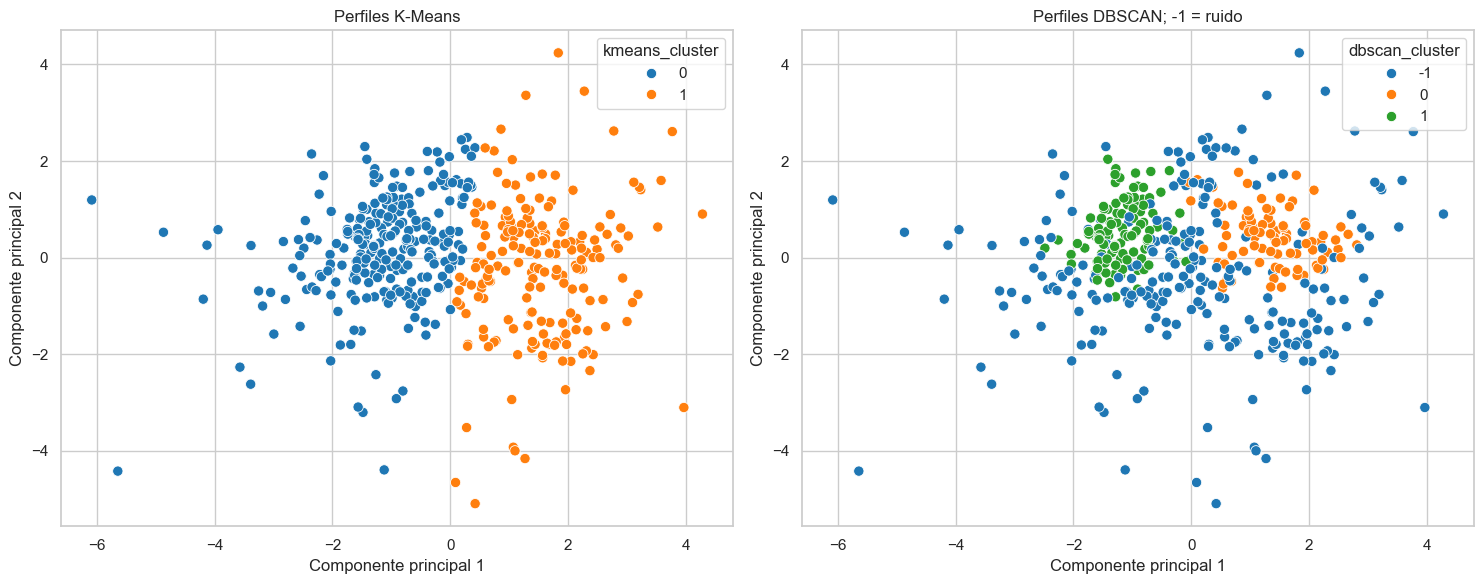

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
kmeans_cluster,,,,,,
0,10348.0,1871.0,2406.0,2225.0,328.0,750.0
1,5406.0,7690.0,11527.0,1062.0,4495.0,1388.0


Cantidad de clientes por cluster K-Means:


,clientes
kmeans_cluster,
0,252
1,188


Cantidad de clientes por cluster DBSCAN:


,clientes
dbscan_cluster,
-1,248
0,88
1,104


In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['kmeans_cluster'], palette='tab10', ax=axes[0], s=55)
axes[0].set_title('Perfiles K-Means')
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['dbscan_cluster'], palette='tab10', ax=axes[1], s=55)
axes[1].set_title('Perfiles DBSCAN; -1 = ruido')
for ax in axes: ax.set_xlabel('Componente principal 1'); ax.set_ylabel('Componente principal 2')
plt.tight_layout()
plt.show()

profile = df.groupby('kmeans_cluster')[spending_cols].median().round(0)
display(profile)
print('Cantidad de clientes por cluster K-Means:')
display(df['kmeans_cluster'].value_counts().sort_index().rename('clientes').to_frame())
print('Cantidad de clientes por cluster DBSCAN:')
display(df['dbscan_cluster'].value_counts().sort_index().rename('clientes').to_frame())

## 4. Interpretacion y conclusiones

- K-Means entrega grupos compactos alrededor de centroides y permite resumir cada perfil con medianas de gasto.
- DBSCAN aporta una lectura complementaria: encuentra densidades y marca clientes atipicos sin obligarlos a pertenecer a un cluster.
- Los perfiles deben describirse comparando categorias relativas: por ejemplo, clientes orientados a Grocery/Detergents_Paper frente a clientes con mayor peso en Fresh/Frozen.
- Silhouette mas alto y Davies-Bouldin mas bajo indican mejor separacion relativa, pero no prueban que exista una segmentacion comercial definitiva.

**Conclusión:** el clustering permite explorar segmentos útiles para campañas y surtido, aunque conviene validar los perfiles con conocimiento del negocio, repetir el análisis en otros periodos y evaluar estabilidad ante cambios de escala o hiperparametros.

## 5. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del analisis

En este ejercicio no existe una respuesta correcta previamente definida. El algoritmo recibe los gastos de cada cliente y busca clientes con comportamientos parecidos. Por eso los grupos no son “buenos” o “malos”: son perfiles que deben interpretarse con el contexto del negocio.

### Criterio para seleccionar los algoritmos

Se comparan dos estrategias porque responden a preguntas diferentes. K-Means busca grupos compactos y requiere definir cuántos grupos se desean analizar. DBSCAN busca zonas de alta densidad, no obliga a fijar de antemano la cantidad de grupos y puede identificar observaciones atipicas. La comparación permite evaluar si los perfiles encontrados son compactos, separados y útiles para el negocio.

**K-Means.** Primero se elige una cantidad de grupos, K. El algoritmo ubica un centro para cada grupo y asigna cada cliente al centro mas cercano. Luego mueve los centros y repite el proceso hasta que los grupos se estabilizan. Es util para encontrar perfiles relativamente compactos, pero hay que decidir K y cada cliente debe quedar asignado a algun grupo.

**DBSCAN.** No necesita indicar de antemano cuántos grupos existen. Busca zonas donde hay muchos clientes cercanos entre si. Los clientes aislados pueden quedar como ruido, identificados con la etiqueta `-1`. Es valioso para encontrar perfiles irregulares y detectar clientes atipicos, aunque depende bastante de los parametros `eps` y `min_samples`.

### Preparacion y criterios de evaluacion

Los gastos tienen escalas muy distintas y algunos clientes gastan muchisimo mas que el promedio. `log1p` reduce el peso de esas diferencias extremas y la estandarizacion coloca las categorias en escalas comparables. Asi, una categoria no domina el agrupamiento solo porque sus numeros sean mas grandes.

- **Silhouette:** indica si cada cliente esta mas cerca de su propio grupo que de los otros. Valores mayores suelen indicar grupos mejor separados.
- **Davies-Bouldin:** compara la dispersion interna de los grupos con la distancia entre ellos. Valores menores suelen ser mejores.
- **Cantidad de clientes por grupo:** ayuda a saber si un perfil es relevante o si solo contiene unos pocos casos.
- **Perfil por medianas:** resume el gasto tipico de cada grupo y permite ponerle un nombre comprensible, como “clientes orientados a productos frescos” o “clientes con alto gasto en grocery y detergentes”.

La proyeccion PCA del grafico reduce seis categorias a dos ejes para poder visualizar los datos. Es una ayuda visual: que dos puntos se vean cerca en el grafico no significa necesariamente que sean iguales en todas las dimensiones originales.

**Decision final:** un segmento es util cuando es interpretable, tiene suficiente cantidad de clientes, presenta una buena separacion y se mantiene razonablemente estable. Antes de tomar decisiones comerciales conviene validarlo con expertos del negocio y con datos de otros periodos.